# PINN for a 1D hyperelastic bar

This notebook solves a forward hyperelasticity problem on the reference interval

$$
x\in[0,L], \qquad L=1.
$$

The manufactured displacement is

$$
u(x)=aX(1-x),
$$

with the boundary conditions

$$
u(0)=0, \qquad u(1)=0.
$$

The material is described by the Saint-Venant--Kirchhoff energy

$$
W=\frac{1}{2}E E_{\mathrm{GL}}^2,
\qquad
E_{\mathrm{GL}}=\frac{1}{2}(F^2-1),
\qquad
F=1+\frac{\mathrm du}{\mathrm dx}.
$$

The first Piola--Kirchhoff stress and equilibrium equation are

$$
P=\frac{\partial W}{\partial F}=E E_{\mathrm{GL}}F,
\qquad
\frac{\mathrm dP}{\mathrm dx}+B=0.
$$

The body force is manufactured from the exact displacement so that the analytical solution is known. The train, validation, and test sets are mutually independent in their roles: training points update the network, validation points select the best checkpoint, and test points are used only for the final evaluation.

## 1. Imports

In [1]:
import copy
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

OUTPUT_DIR = Path("imgs")
OUTPUT_DIR.mkdir(exist_ok=True)

/home/eliska/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 2. Settings

The split sizes and optimizer settings follow the reference 1D notebook. The amplitude must satisfy $0<a<1$ so that $F>0$ everywhere.

In [2]:
USE_DATA = False  
DATA_MODE = "exact" 
NOISE_RELATIVE_STD = 0.02


L = 1.0
E_YOUNG = 1.0
A = 0.2


N_PDE_TRAIN = 1000
N_PDE_VALIDATION = 100
N_PDE_TEST = 100
PDE_BATCH_SIZE = 16

N_DATA_TRAIN = 10
N_DATA_VALIDATION = 5
N_DATA_TEST = 5

EPOCHS = 2000
LBFGS_EPOCHS = 100
ADAM_EPOCHS = EPOCHS - LBFGS_EPOCHS
LR = 1e-3
SEED = 42

torch.manual_seed(SEED)

## 3. Exact solution and manufactured body force

For

$$
u(x)=aX(1-x),
$$

the exact deformation gradient is

$$
F(x)=1+a(1-2x).
$$

Since

$$
P=\frac{E}{2}(F^3-F),
$$

the body force required by equilibrium is

$$
B(x)=-\frac{\mathrm dP}{\mathrm dx}
=aE\left(3F^2-1\right).
$$

In [3]:
def exact_displacement(x):
    return A * x * (L - x)


def exact_deformation_gradient(x):
    return 1.0 + A * (L - 2.0 * x)


def exact_green_lagrange_strain(x):
    F = exact_deformation_gradient(x)
    return 0.5 * (F**2 - 1.0)


def exact_nominal_stress(x):
    F = exact_deformation_gradient(x)
    return E_YOUNG * exact_green_lagrange_strain(x) * F


def body_force(x):
    F = exact_deformation_gradient(x)
    return A * E_YOUNG * (3.0 * F**2 - 1.0)


def observed_displacement(x, seed):
    exact = exact_displacement(x)
    if DATA_MODE == "exact":
        return exact

    maximum_displacement = A * L**2 / 4.0
    generator = torch.Generator().manual_seed(seed)
    noise = torch.randn(exact.shape, generator=generator, dtype=exact.dtype)
    return exact + NOISE_RELATIVE_STD * maximum_displacement * noise

## 4. Neural network

In [4]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 10),
            nn.Tanh(),
            nn.Linear(10, 10),
            nn.Tanh(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        return self.net(x)


model = PINN()
optimizer_adam = torch.optim.Adam(model.parameters(), lr=LR)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Trainable parameters: 141


## 5. PDE train, validation, and test points

All three PDE sets are uniform interior grids with different within-cell shifts. The shifts make the training, validation, and test coordinates mutually disjoint. Training points update the network, validation points select the best checkpoint, and test points remain unused until the final evaluation.

In [5]:
def shifted_uniform_grid(number_of_points, shift):
    indices = torch.arange(number_of_points, dtype=torch.get_default_dtype())
    return (L * (indices + shift) / number_of_points).view(-1, 1)


def grids_overlap(first, second):
    distances = torch.abs(first[:, None, 0] - second[None, :, 0])
    return bool(torch.any(distances < 1e-12))


x_pde_train = shifted_uniform_grid(N_PDE_TRAIN, shift=0.50)
x_pde_validation = shifted_uniform_grid(N_PDE_VALIDATION, shift=0.37)
x_pde_test = shifted_uniform_grid(N_PDE_TEST, shift=0.73)


print(f"PDE points: {N_PDE_TRAIN} train, {N_PDE_VALIDATION} validation, {N_PDE_TEST} test")
print("PDE grids overlap: False")
print(f"Adam PDE batch size: {PDE_BATCH_SIZE}")

pde_batch_generator = torch.Generator().manual_seed(SEED + 1)
pde_train_loader = DataLoader(
    TensorDataset(x_pde_train),
    batch_size=PDE_BATCH_SIZE,
    shuffle=True,
    generator=pde_batch_generator,
)

PDE points: 1000 train, 100 validation, 100 test
PDE grids overlap: False
Adam PDE batch size: 16


## 6. Optional supervised displacement data

Set `DATA_MODE` to `"exact"` or `"noisy"`. In noisy mode, independent Gaussian noise is added to the train, validation, and test observations. The standard deviation is specified relative to the maximum exact displacement.

In [6]:
if USE_DATA:
    x_data_train = torch.linspace(0.0, L, N_DATA_TRAIN + 2)[1:-1].view(-1, 1)

    data_validation_generator = torch.Generator().manual_seed(455)
    x_data_validation = L * torch.rand(
        N_DATA_VALIDATION, 1, generator=data_validation_generator
    )
    x_data_validation, _ = torch.sort(x_data_validation, dim=0)

    data_test_generator = torch.Generator().manual_seed(456)
    x_data_test = L * torch.rand(
        N_DATA_TEST, 1, generator=data_test_generator
    )
    x_data_test, _ = torch.sort(x_data_test, dim=0)

    u_data_train = observed_displacement(x_data_train, seed=SEED + 20)
    u_data_validation = observed_displacement(x_data_validation, seed=SEED + 21)
    u_data_test = observed_displacement(x_data_test, seed=SEED + 22)

    print(f"Displacement data: {N_DATA_TRAIN} train, {N_DATA_VALIDATION} validation, {N_DATA_TEST} test")
    print(f"Displacement data mode: {DATA_MODE}")

## 7. Physics residual and training

The network approximates $u_\theta(X)$. Automatic differentiation gives

$$
F_\theta=1+u_\theta',
\qquad
E_{\mathrm{GL},\theta}=\frac{1}{2}(F_\theta^2-1),
\qquad
P_\theta=E E_{\mathrm{GL},\theta}F_\theta.
$$

The PDE residual is

$$
r_\theta=P_\theta'+B.
$$

In [7]:
loss_history = []
pde_loss_history = []
bc_loss_history = []
data_loss_history = []
validation_loss_history = []
validation_pde_loss_history = []
validation_data_loss_history = []

best_validation_loss = float("inf")
best_validation_pde_loss = None
best_validation_data_loss = None
best_epoch = None
best_model_state = None


def displacement_stress_and_residual(x, create_graph):
    x_local = x.detach().clone().requires_grad_(True)
    u = model(x_local)
    du = torch.autograd.grad(u, x_local, torch.ones_like(u), create_graph=True)[0]
    F = 1.0 + du
    E_gl = 0.5 * (F**2 - 1.0)
    P = E_YOUNG * E_gl * F
    dP = torch.autograd.grad(P, x_local, torch.ones_like(P), create_graph=create_graph)[0]
    residual = dP + body_force(x_local)
    return u, P, residual


def compute_training_losses(x_pde):
    _, _, residual = displacement_stress_and_residual(x_pde, create_graph=True)
    loss_pde = torch.mean(residual**2)
    loss_bc = model(torch.tensor([[0.0]])).square().mean()
    loss_bc = loss_bc + model(torch.tensor([[L]])).square().mean()
    loss_data = (torch.mean((model(x_data_train) - u_data_train)**2)
        if USE_DATA else torch.tensor(0.0))
    loss = loss_pde + loss_bc + loss_data
    return loss, loss_pde, loss_bc, loss_data


def compute_validation_losses():
    _, _, residual = displacement_stress_and_residual(
        x_pde_validation, create_graph=False)
    loss_pde = torch.mean(residual.detach()**2)
    with torch.no_grad():
        loss_data = (torch.mean((model(x_data_validation) - u_data_validation)**2)
            if USE_DATA else torch.tensor(0.0))
    return loss_pde + loss_data, loss_pde, loss_data


def update_checkpoint(epoch):
    global best_validation_loss, best_validation_pde_loss
    global best_validation_data_loss, best_epoch, best_model_state

    model.eval()
    loss, loss_pde, loss_data = compute_validation_losses()
    values = loss.item(), loss_pde.item(), loss_data.item()
    validation_loss_history.append(values[0])
    validation_pde_loss_history.append(values[1])
    validation_data_loss_history.append(values[2])

    if best_model_state is None or values[0] < best_validation_loss:
        best_validation_loss = values[0]
        best_validation_pde_loss = values[1]
        best_validation_data_loss = values[2]
        best_epoch = epoch
        best_model_state = copy.deepcopy(model.state_dict())

    model.train()
    return values[0]


for epoch in range(ADAM_EPOCHS):
    epoch_sums = np.zeros(4)
    samples = 0

    for (x_pde_batch,) in pde_train_loader:
        optimizer_adam.zero_grad(set_to_none=True)
        losses = compute_training_losses(x_pde_batch)
        losses[0].backward()
        optimizer_adam.step()

        batch_size = len(x_pde_batch)
        epoch_sums += np.array(
            [value.detach().item() for value in losses]
        ) * batch_size
        samples += batch_size

    epoch_values = epoch_sums / samples
    loss_history.append(epoch_values[0])
    pde_loss_history.append(epoch_values[1])
    bc_loss_history.append(epoch_values[2])
    data_loss_history.append(epoch_values[3])
    validation_value = update_checkpoint(epoch)

    if epoch % 100 == 0:
        print(
            f"Adam | epoch {epoch:5d} | loss={epoch_values[0]:.3e} "
            f"| PDE={epoch_values[1]:.3e} | BC={epoch_values[2]:.3e} "
            f"| validation={validation_value:.3e}"
        )


optimizer_lbfgs = torch.optim.LBFGS(
    model.parameters(), lr=0.1, max_iter=20,
    history_size=50, line_search_fn="strong_wolfe"
)

for lbfgs_epoch in range(LBFGS_EPOCHS):
    epoch = ADAM_EPOCHS + lbfgs_epoch

    def closure():
        optimizer_lbfgs.zero_grad(set_to_none=True)
        loss, _, _, _ = compute_training_losses(x_pde_train)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    loss, loss_pde, loss_bc, loss_data = compute_training_losses(x_pde_train)
    loss_history.append(loss.detach().item())
    pde_loss_history.append(loss_pde.detach().item())
    bc_loss_history.append(loss_bc.detach().item())
    data_loss_history.append(loss_data.detach().item())
    validation_value = update_checkpoint(epoch)

    if lbfgs_epoch % 50 == 0 or lbfgs_epoch == LBFGS_EPOCHS - 1:
        print(
            f"L-BFGS | epoch {epoch:5d} | loss={loss.item():.3e} "
            f"| validation={validation_value:.3e}"
        )


last_model_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_model_state)
model.eval()

print(f"Best epoch: {best_epoch}")
print(f"Best combined validation loss: {best_validation_loss:.6e}")
print(f"Validation PDE MSE: {best_validation_pde_loss:.6e}")
print(f"Validation data MSE: {best_validation_data_loss:.6e}")

Adam | epoch     0 | loss=1.403e-01 | PDE=1.044e-01 | BC=3.588e-02 | validation=1.625e-02
Adam | epoch   100 | loss=6.072e-06 | PDE=5.001e-06 | BC=1.071e-06 | validation=4.698e-06
Adam | epoch   200 | loss=3.880e-06 | PDE=3.272e-06 | BC=6.083e-07 | validation=2.524e-06
Adam | epoch   300 | loss=2.713e-06 | PDE=2.207e-06 | BC=5.056e-07 | validation=1.675e-06
Adam | epoch   400 | loss=1.918e-06 | PDE=1.414e-06 | BC=5.043e-07 | validation=9.133e-07
Adam | epoch   500 | loss=2.790e-06 | PDE=1.693e-06 | BC=1.097e-06 | validation=8.990e-07
Adam | epoch   600 | loss=8.365e-07 | PDE=4.919e-07 | BC=3.446e-07 | validation=5.702e-07
Adam | epoch   700 | loss=4.475e-07 | PDE=2.627e-07 | BC=1.847e-07 | validation=1.727e-07
Adam | epoch   800 | loss=1.331e-06 | PDE=5.538e-07 | BC=7.777e-07 | validation=9.171e-07
Adam | epoch   900 | loss=5.524e-07 | PDE=1.880e-07 | BC=3.644e-07 | validation=1.311e-07
Adam | epoch  1000 | loss=4.887e-07 | PDE=2.320e-07 | BC=2.568e-07 | validation=3.076e-08
Adam | epo

## 8. Final test metrics

In [8]:
model.eval()
u_test, P_test, residual_test = displacement_stress_and_residual(
    x_pde_test, create_graph=False
)

u_test = u_test.detach()
P_test = P_test.detach()
residual_test = residual_test.detach()
u_exact_test = exact_displacement(x_pde_test)
P_exact_test = exact_nominal_stress(x_pde_test)


def relative_l2(prediction, exact):
    return (
        torch.linalg.vector_norm(prediction - exact)
        / torch.linalg.vector_norm(exact)
    ).item()


def r2_score(prediction, exact):
    ss_res = torch.sum((prediction - exact)**2)
    ss_tot = torch.sum((exact - torch.mean(exact))**2)
    return (1.0 - ss_res / ss_tot).item()


metrics = {
    "best_epoch": best_epoch,
    "best_validation_loss": best_validation_loss,
    "displacement_R2_test": r2_score(u_test, u_exact_test),
    "displacement_relative_L2_test": relative_l2(u_test, u_exact_test),
    "nominal_stress_R2_test": r2_score(P_test, P_exact_test),
    "nominal_stress_relative_L2_test": relative_l2(P_test, P_exact_test),
    "PDE_test_MSE": torch.mean(residual_test**2).item(),
}

print("=" * 58)
print("HYPERELASTIC PINN TEST RESULTS")
print("=" * 58)
print(f"Displacement R2:              {metrics['displacement_R2_test']:.8f}")
print(f"Displacement relative L2:     {metrics['displacement_relative_L2_test']:.6e}")
print(f"Nominal stress R2:            {metrics['nominal_stress_R2_test']:.8f}")
print(f"Nominal stress relative L2:   {metrics['nominal_stress_relative_L2_test']:.6e}")
print(f"PDE residual MSE:             {metrics['PDE_test_MSE']:.6e}")
print("=" * 58)

metrics

HYPERELASTIC PINN TEST RESULTS
Displacement R2:              0.99999952
Displacement relative L2:     2.895835e-04
Nominal stress R2:            0.99999994
Nominal stress relative L2:   2.431839e-04
PDE residual MSE:             8.103330e-09


{'best_epoch': 1319,
 'best_validation_loss': 7.578010219333464e-09,
 'displacement_R2_test': 0.9999995231628418,
 'displacement_relative_L2_test': 0.00028958346229046583,
 'nominal_stress_R2_test': 0.9999999403953552,
 'nominal_stress_relative_L2_test': 0.00024318390933331102,
 'PDE_test_MSE': 8.103330451092461e-09}

## 9. Plots

In [9]:
def predict_u_and_P(x, state_dict=None):
    current_state = copy.deepcopy(model.state_dict())
    if state_dict is not None:
        model.load_state_dict(state_dict)
    model.eval()
    u, P, _ = displacement_stress_and_residual(x, create_graph=False)
    model.load_state_dict(current_state)
    model.eval()
    return u.detach(), P.detach()


x_plot = torch.linspace(0.0, L, 400).view(-1, 1)
u_best, P_best = predict_u_and_P(x_plot, best_model_state)
u_last, P_last = predict_u_and_P(x_plot, last_model_state)
u_exact_plot = exact_displacement(x_plot)
P_exact_plot = exact_nominal_stress(x_plot)


def plot_data_split():
    ncols = 2 if USE_DATA else 1
    fig, axes = plt.subplots(1, ncols, figsize=(7 * ncols, 4.5))
    if ncols == 1:
        axes = [axes]

    axes[0].scatter(x_pde_train, 2 * torch.ones_like(x_pde_train), s=18,
                    color="tab:blue", label=f"PDE train ({N_PDE_TRAIN})")
    axes[0].scatter(x_pde_validation, torch.ones_like(x_pde_validation), s=24,
                    color="tab:green", marker="s", label=f"PDE validation ({N_PDE_VALIDATION})")
    axes[0].scatter(x_pde_test, torch.zeros_like(x_pde_test), s=24,
                    color="tab:orange", marker="x", label=f"PDE test ({N_PDE_TEST})")
    axes[0].set_yticks([0, 1, 2], labels=["test", "validation", "train"])
    axes[0].set(xlabel="X", title="Collocation points", ylim=(-0.5, 2.5))
    axes[0].grid(axis="x")
    axes[0].legend()

    if USE_DATA:
        axes[1].plot(x_plot, u_exact_plot, "k--", label="Exact displacement")
        axes[1].scatter(x_data_train, u_data_train, s=45, color="tab:blue",
                        label=f"Data train ({N_DATA_TRAIN})", zorder=3)
        axes[1].scatter(x_data_validation, u_data_validation, s=45,
                        color="tab:green", marker="s",
                        label=f"Data validation ({N_DATA_VALIDATION})", zorder=3)
        axes[1].scatter(x_data_test, u_data_test, s=45,
                        color="tab:orange", marker="x",
                        label=f"Data test ({N_DATA_TEST})", zorder=3)
        axes[1].set(
            xlabel="X", ylabel="u(X)",
            title=f"Supervised displacement data ({DATA_MODE})",
        )
        axes[1].grid()
        axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_points_and_data_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_solution():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(x_plot, u_exact_plot, "k--", linewidth=2, label="Exact")
    axes[0].plot(x_plot, u_best, linewidth=2, label=f"Best epoch ({best_epoch})")
    axes[0].plot(x_plot, u_last, ":", linewidth=2, label="Last epoch")
    axes[0].set(xlabel="X", ylabel="u(X)", title="Displacement")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(x_plot, P_exact_plot, "k--", linewidth=2, label="Exact")
    axes[1].plot(x_plot, P_best, linewidth=2, label=f"Best epoch ({best_epoch})")
    axes[1].plot(x_plot, P_last, ":", linewidth=2, label="Last epoch")
    axes[1].set(xlabel="X", ylabel="P(X)", title="First Piola--Kirchhoff stress")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_solution_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_losses():
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

    axes[0].plot(loss_history, alpha=0.65, label="total")
    axes[0].plot(pde_loss_history,alpha=0.6 ,label="PDE")
    axes[0].plot(bc_loss_history, alpha=0.6, label="boundary conditions")
    if USE_DATA:
        axes[0].plot(data_loss_history, label="supervised data")
    axes[0].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[0].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[0].set_yscale("log")
    axes[0].set(xlabel="epoch", ylabel="loss", title="Training losses")
    axes[0].grid()
    axes[0].legend()

    axes[1].plot(validation_loss_history,alpha=0.65, label="combined validation")
    axes[1].plot(validation_pde_loss_history,alpha=0.65, label="PDE")
    if USE_DATA:
        axes[1].plot(validation_data_loss_history, label="data")
    axes[1].axvline(ADAM_EPOCHS, color="black", linestyle=":", label="switch to L-BFGS")
    axes[1].axvline(best_epoch, color="tab:green", linestyle="--", label=f"best epoch ({best_epoch})")
    axes[1].set_yscale("log")
    axes[1].set(xlabel="epoch", ylabel="loss", title="Validation losses")
    axes[1].grid()
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_losses_1D.pdf", bbox_inches="tight")
    plt.show()


def plot_errors():
    u_error = torch.abs(u_best - u_exact_plot) / torch.max(torch.abs(u_exact_plot))
    P_error = torch.abs(P_best - P_exact_plot) / torch.max(torch.abs(P_exact_plot))

    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    axes[0].plot(x_plot, u_error)
    axes[0].set(xlabel="X", ylabel="normalized absolute error",
                title="Displacement error")
    axes[0].grid()

    axes[1].plot(x_plot, P_error)
    axes[1].set(xlabel="X", ylabel="normalized absolute error",
                title="First Piola--Kirchhoff stress error")
    axes[1].grid()

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "hyperelastic_errors_1D.pdf", bbox_inches="tight")
    plt.show()

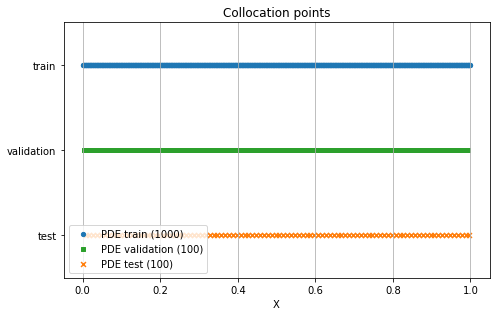

In [10]:
plot_data_split()

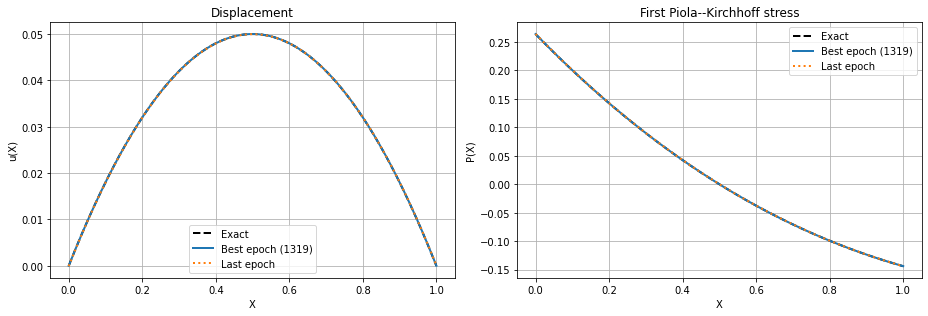

In [11]:
plot_solution()

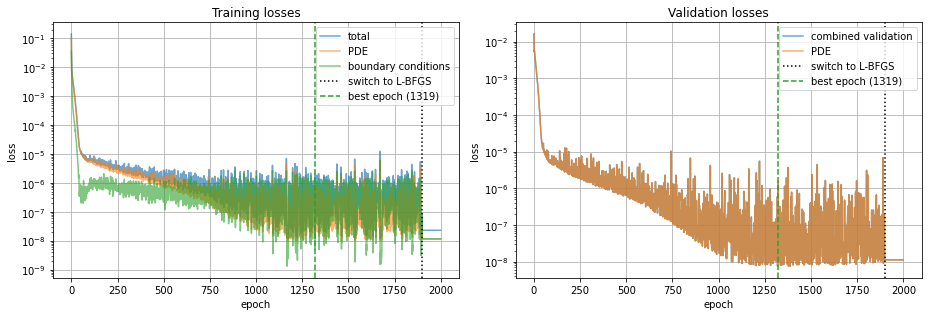

In [12]:
plot_losses()

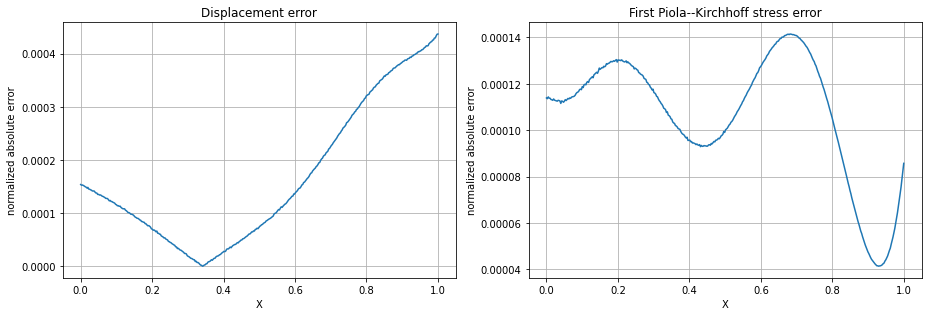

In [13]:
plot_errors()